# Linking PG&E utility data with building polygons
This notebook will take Global Building Atlas polygons and link to the nearest PG&E feeder line.

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import box
from shapely.geometry import MultiLineString
import matplotlib.pyplot as plt
import glob
import os
import folium

In [2]:
pd.set_option('display.max_columns', None)

# 1a. LineDetail.shp

In [3]:
pge_linedetail = gpd.read_file("../../../../capstone/electrigrid/data/utilities/pge_shapefiles/LineDetail.shp")

<Axes: >

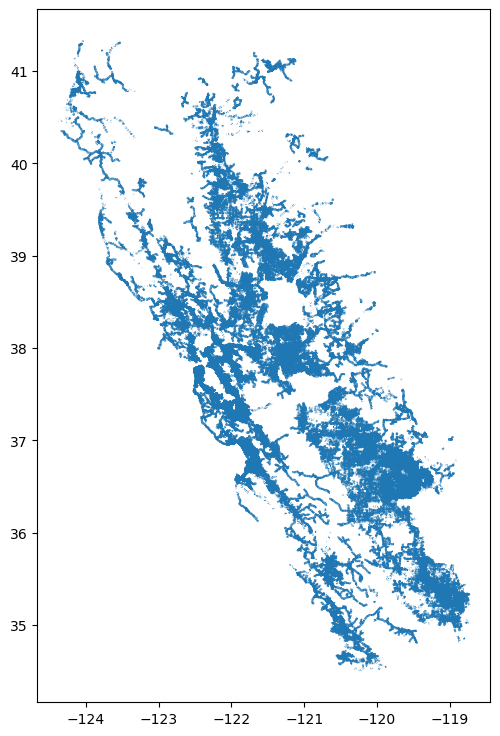

In [13]:
fig, ax = plt.subplots(figsize=(10, 9))
pge_linedetail.plot(ax=ax)

In [4]:
pge_linedetail = pge_linedetail.to_crs("EPSG:4326")

Test bbox: -121.977774, 37.324955, -121.879069, 37.375036 (EPSG:4326)

In [5]:
bbox = box(minx=-121.977774, miny=37.324955, maxx=-121.879069, maxy=37.375036 )
bbox = gpd.GeoDataFrame(geometry=[bbox], crs=pge_linedetail.crs)

In [6]:
bbox_circuits = gpd.clip(pge_linedetail, bbox)

In [8]:
bbox_circuits.head()

,FeederId,FeederName,globalid,CSV_LineSe,LoadCapaci,voltage_kv,phase_cnt,limiting_m,limiting_c,ICA_Analys,lica_analy,Division,GenCapacit,GenericPVC,GenCapac_1,GenericCap,limiting_1,limiting_2,limiting_3,limiting_4,limiting_5,limiting_6,limiting_7,limiting_8,ScreenL,Publish,Last_Updat,SHAPE_Leng,geometry
489731,082261116,SAN JOSE B 1116,{ED77C806-BE83-4A08-9739-FFC1E7FE4568},4728073,2522,12.0,3,7_18,Voltage,Nov 2025,Nov 2025,San Jose,0,0,0,0,Safety,"5_0, 5_1, 5_10, 5_11, 5_12, 5_13, 5_14, 5_15, ...",Safety,"5_0, 5_1, 5_10, 5_11, 5_12, 5_13, 5_14, 5_15, ...",Safety,"5_0, 5_1, 5_10, 5_11, 5_12, 5_13, 5_14, 5_15, ...",Safety,"5_0, 5_1, 5_10, 5_11, 5_12, 5_13, 5_14, 5_15, ...",Likely to pass,1,2025-12-01,45.547215,"LINESTRING (-121.94143 37.32551, -121.94142 37..."
555042,082261116,SAN JOSE B 1116,{883B33B4-5651-4C72-BD6C-175770B2FE3A},4244747,2623,12.0,3,7_18,Voltage,Nov 2025,Nov 2025,San Jose,0,0,0,0,Safety,"5_0, 5_1, 5_10, 5_11, 5_12, 5_13, 5_14, 5_15, ...",Safety,"5_0, 5_1, 5_10, 5_11, 5_12, 5_13, 5_14, 5_15, ...",Safety,"5_0, 5_1, 5_10, 5_11, 5_12, 5_13, 5_14, 5_15, ...",Safety,"5_0, 5_1, 5_10, 5_11, 5_12, 5_13, 5_14, 5_15, ...",Likely to pass,1,2025-12-01,18.491541,"LINESTRING (-121.94164 37.32560, -121.94164 37..."
551270,082261116,SAN JOSE B 1116,{55F69CBB-399F-4B2D-8B97-A97FDFF9CE9E},5232881,2571,12.0,3,7_18,Voltage,Nov 2025,Nov 2025,San Jose,0,0,0,0,Safety,"5_0, 5_1, 5_10, 5_11, 5_12, 5_13, 5_14, 5_15, ...",Safety,"5_0, 5_1, 5_10, 5_11, 5_12, 5_13, 5_14, 5_15, ...",Safety,"5_0, 5_1, 5_10, 5_11, 5_12, 5_13, 5_14, 5_15, ...",Safety,"5_0, 5_1, 5_10, 5_11, 5_12, 5_13, 5_14, 5_15, ...",Likely to pass,1,2025-12-01,4.273291,"LINESTRING (-121.94164 37.32560, -121.94166 37..."
551272,082261116,SAN JOSE B 1116,{0E8C0C1C-0C66-4B60-AFBF-0A475BD7E459},3169444,2612,12.0,3,7_18,Voltage,Nov 2025,Nov 2025,San Jose,0,0,0,0,Safety,"5_0, 5_1, 5_10, 5_11, 5_12, 5_13, 5_14, 5_15, ...",Safety,"5_0, 5_1, 5_10, 5_11, 5_12, 5_13, 5_14, 5_15, ...",Safety,"5_0, 5_1, 5_10, 5_11, 5_12, 5_13, 5_14, 5_15, ...",Safety,"5_0, 5_1, 5_10, 5_11, 5_12, 5_13, 5_14, 5_15, ...",Likely to pass,1,2025-12-01,34.848612,"LINESTRING (-121.94151 37.32551, -121.94151 37..."
351253,082261110,SAN JOSE B 1110,{3AE1A845-553E-4269-AA3E-7DC25C1A9FE1},3512413,1030,12.0,3,None,None,Feb 2025,Feb 2025,San Jose,1890,2350,1890,2350,None,None,None,None,None,None,None,None,Likely to pass,1,2025-06-02,83.469990,"LINESTRING (-121.93187 37.32499, -121.93187 37..."


<Axes: >

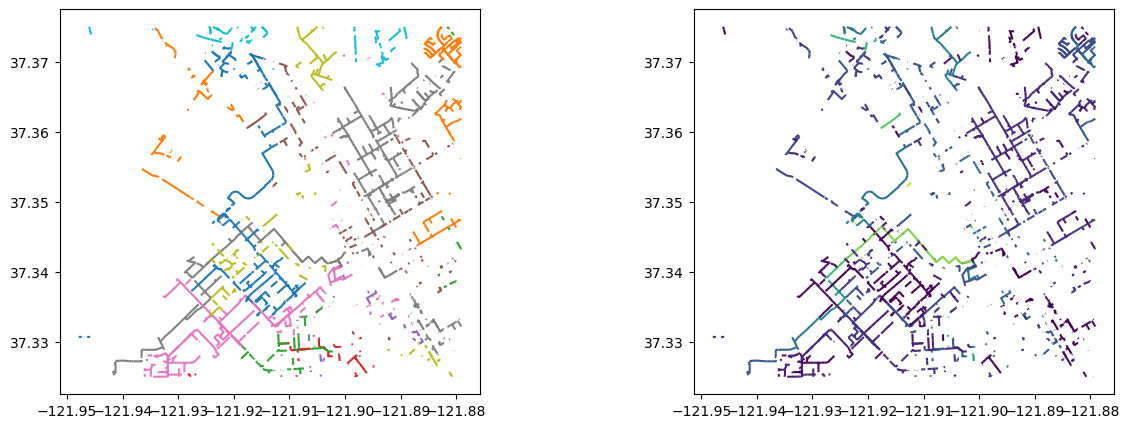

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
bbox_circuits.plot(ax=axes[0], column='FeederName')
bbox_circuits.plot(ax=axes[1], column='LoadCapaci')